In [1]:
import torch
import os

# Match PyTorch version
TORCH = torch.__version__
print("Torch version:", TORCH)

# Install PyG dependencies (version-matched)
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-{TORCH}.html
!pip install torch-geometric

Torch version: 2.10.0+cpu
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 16.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.5 MB/s eta 0:00:00


In [2]:
from torch_geometric.datasets import PPI

dataset = PPI(root='data/PPI')

print(dataset)
print(dataset[0])

Extracting data/PPI/ppi.zip
Processing...


PPI(20)
Data(x=[1767, 50], edge_index=[2, 32318], y=[1767, 121])


Done!


In [3]:
data = dataset[0]
data.edge_attr = torch.ones(data.edge_index.size(1), 1)

In [4]:
import torch_geometric.transforms as T

transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    neg_sampling_ratio=2.0,
    add_negative_train_samples=False
)

train_data, val_data, test_data = transform(data)

In [5]:
from torch_geometric.loader import LinkNeighborLoader

train_loader = LinkNeighborLoader(
    data=train_data,
    num_neighbors=[20, 10],
    neg_sampling_ratio=2.0,
    edge_label_index=train_data.edge_label_index,
    edge_label=train_data.edge_label,
    batch_size=128,
    shuffle=True,
)

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=val_data.edge_label_index,
    edge_label=val_data.edge_label,
    batch_size=128,
    shuffle=False,
)

In [6]:
from torch_geometric.nn import MessagePassing
import torch.nn as nn
import torch.nn.functional as F

class GNNLayer(MessagePassing):
    def __init__(self, hidden_channels):
        super().__init__(aggr='mean')
        self.lin = nn.Linear(hidden_channels, hidden_channels)

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_j, edge_attr):
        return x_j * (1 + edge_attr)

    def update(self, aggr_out, x):
        return self.lin(aggr_out + x)

In [7]:
class LinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()

        self.lin = nn.Linear(in_channels, hidden_channels)

        self.conv1 = GNNLayer(hidden_channels)
        self.conv2 = GNNLayer(hidden_channels)

        self.edge_lin = nn.Linear(1, 1)

    def forward(self, data):
        x = self.lin(data.x)
        edge_index = data.edge_index
        edge_attr = data.edge_attr

        # GNN
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr)

        # Link prediction
        edge_label_index = data.edge_label_index

        x_i = x[edge_label_index[0]]
        x_j = x[edge_label_index[1]]

        pred = (x_i * x_j).sum(dim=-1)

        # edge feature contribution
        edge_attr = edge_attr[:edge_label_index.size(1)]
        edge_attr = self.edge_lin(edge_attr).view(-1)

        pred = pred + edge_attr

        return pred

In [8]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = LinkPredictor(in_channels=50, hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
for epoch in range(1, 31):
    model.train()
    total_loss = 0
    num_batches = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(batch)
        ground_truth = batch.edge_label.float()

        loss = F.binary_cross_entropy_with_logits(pred, ground_truth)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.6033
Epoch 2, Loss: 0.5013
Epoch 3, Loss: 0.4623
Epoch 4, Loss: 0.4392
Epoch 5, Loss: 0.4198
Epoch 6, Loss: 0.4099
Epoch 7, Loss: 0.3979
Epoch 8, Loss: 0.3936
Epoch 9, Loss: 0.3866
Epoch 10, Loss: 0.3813
Epoch 11, Loss: 0.3747
Epoch 12, Loss: 0.3697
Epoch 13, Loss: 0.3687
Epoch 14, Loss: 0.3621
Epoch 15, Loss: 0.3665
Epoch 16, Loss: 0.3629
Epoch 17, Loss: 0.3593
Epoch 18, Loss: 0.3565
Epoch 19, Loss: 0.3520
Epoch 20, Loss: 0.3516
Epoch 21, Loss: 0.3496
Epoch 22, Loss: 0.3467
Epoch 23, Loss: 0.3490
Epoch 24, Loss: 0.3476
Epoch 25, Loss: 0.3479
Epoch 26, Loss: 0.3455
Epoch 27, Loss: 0.3398
Epoch 28, Loss: 0.3386
Epoch 29, Loss: 0.3423
Epoch 30, Loss: 0.3415


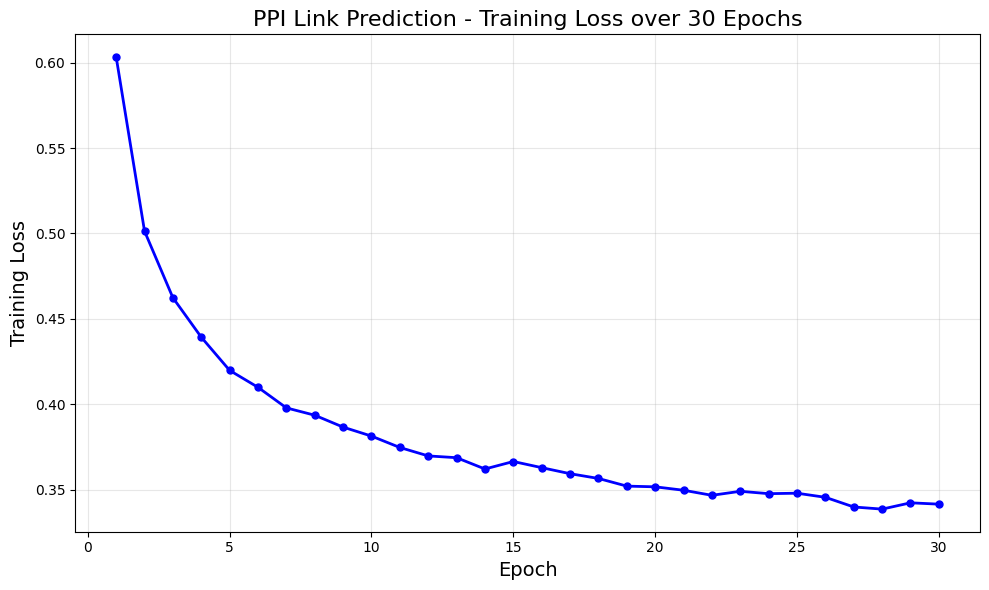

Saved: ppi_training_loss.png


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), train_losses, 'b-o', linewidth=2, markersize=5)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Training Loss', fontsize=14)
plt.title('PPI Link Prediction - Training Loss over 30 Epochs', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 31, 5))
plt.tight_layout()
plt.savefig('ppi_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ppi_training_loss.png')

In [10]:
model.eval()
preds, gts = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)

        pred = torch.sigmoid(model(batch))
        preds.append(pred)
        gts.append(batch.edge_label)

pred_all = torch.cat(preds).cpu().numpy()
gt_all = torch.cat(gts).cpu().numpy()

auc = roc_auc_score(gt_all, pred_all)
print("Validation AUC:", auc)

Validation AUC: 0.9043190239325951
